In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.options.display.float_format = '{:.2f}'.format

In [57]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [58]:
path = os.path.join("..","data","raw", "AmesHousing.csv")
df = pd.read_csv(path, keep_default_na=False, na_values=['','NA']) # by default pandas interprets None values in categorical columns as NANs

### Initial data exploration


In [59]:
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (2930, 82)
Order                int64
PID                  int64
MS SubClass          int64
MS Zoning              str
Lot Frontage       float64
Lot Area             int64
Street                 str
Alley                  str
Lot Shape              str
Land Contour           str
Utilities              str
Lot Config             str
Land Slope             str
Neighborhood           str
Condition 1            str
Condition 2            str
Bldg Type              str
House Style            str
Overall Qual         int64
Overall Cond         int64
Year Built           int64
Year Remod/Add       int64
Roof Style             str
Roof Matl              str
Exterior 1st           str
Exterior 2nd           str
Mas Vnr Type           str
Mas Vnr Area       float64
Exter Qual             str
Exter Cond             str
Foundation             str
Bsmt Qual              str
Bsmt Cond              str
Bsmt Exposure          str
BsmtFin Type 1         str
BsmtFin SF 1       float64
BsmtFin Ty

Gaining statistical information about the numeric columns

In [60]:
df.drop(['Order', 'PID'], axis=1).describe(include=['int64', 'float64'], percentiles=[0.5]).drop(['count']).T

,mean,std,min,50%,max
MS SubClass,57.39,42.64,20.00,50.00,190.00
Lot Frontage,69.22,23.37,21.00,68.00,313.00
Lot Area,10147.92,7880.02,1300.00,9436.50,215245.00
Overall Qual,6.09,1.41,1.00,6.00,10.00
Overall Cond,5.56,1.11,1.00,5.00,9.00
Year Built,1971.36,30.25,1872.00,1973.00,2010.00
Year Remod/Add,1984.27,20.86,1950.00,1993.00,2010.00
Mas Vnr Area,101.90,179.11,0.00,0.00,1600.00
BsmtFin SF 1,442.63,455.59,0.00,370.00,5644.00
BsmtFin SF 2,49.72,169.17,0.00,0.00,1526.00


# Data Cleaning
## 1) Identifying missing values

In [61]:
def print_missing(df: pd.DataFrame):
    missing = df.isna().sum().sort_values(ascending=False)
    print(missing[missing > 0])

In [62]:
print_missing(df)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Type        23
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64


### 1.1) Taking care of the `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Fireplace Qu` columns
Missing values in these columns indicate that a house doesn't have a pool, fireplace or any miscelaneous feature. This hypothesis is supported by the fact, that each entry with a missing Pool QC has a Pool area of 0, Fireplace Qu has number of fireplaces equal to 0 and so on.

In [63]:
pool_na = np.sum(df['Pool Area'] == 0 & df['Pool QC'].isna())
misc_na = np.sum(df['Misc Val'] == 0 & df['Misc Feature'].isna())
fireplace_na = np.sum(df['Fireplaces'] == 0 & df['Fireplace Qu'].isna())

print(f"Rows with missing 'Pool QC' and 'Pool Area' = 0: {pool_na}")
print(f"Rows with missing 'Misc Feature' and 'Misc Val' = 0: {misc_na}")
print(f"Rows with missing 'Fireplace Qu' and 'Fireplaces' = 0: {fireplace_na}")

Rows with missing 'Pool QC' and 'Pool Area' = 0: 2917
Rows with missing 'Misc Feature' and 'Misc Val' = 0: 2827
Rows with missing 'Fireplace Qu' and 'Fireplaces' = 0: 1422


In [64]:
print(df['Alley'].unique().tolist())
print(df['Fence'].unique().tolist())

[nan, 'Pave', 'Grvl']
[nan, 'MnPrv', 'GdPrv', 'GdWo', 'MnWw']


Preparing a copy of the dataframe to be cleaned

In [65]:
df_clean = df.copy()

Filling missing categorical values with `'None'`, according to the previous observations and the dataset documentation.

In [66]:
missing_category = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu']

for colname in missing_category:
    df_clean[colname] = df_clean[colname].fillna('None')

In [67]:
print_missing(df_clean)

Lot Frontage      490
Garage Finish     159
Garage Cond       159
Garage Qual       159
Garage Yr Blt     159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
BsmtFin Type 1     80
Bsmt Qual          80
Mas Vnr Area       23
Mas Vnr Type       23
Bsmt Full Bath      2
Bsmt Half Bath      2
Total Bsmt SF       1
BsmtFin SF 1        1
BsmtFin SF 2        1
Electrical          1
Garage Cars         1
Garage Area         1
Bsmt Unf SF         1
dtype: int64


### 1.2) Now let's take care of the `Garage` related columns

In [68]:
garage_cols = df.columns[df.columns.str.startswith('Garage')]

`Garage Cond`, `Garage Finish`, `Garage Qual`, `Garage Yr Blt` have 159 missing values, whereas `Garage Type` has only 157 NAs. `Garage Cars` and `Garage Area` have only 1 missing value. Let's inspect the data to find any patterns.

In [69]:
df_clean.loc[(~df_clean['Garage Type'].isna()) & (df_clean['Garage Qual'].isna()), garage_cols]

,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond
1356,Detchd,NaN,NaN,1.00,360.00,NaN,NaN
2236,Detchd,NaN,NaN,NaN,NaN,NaN,NaN


We can assume, that these records hold invalid data and point to houses with no garage.


Adjusting inconsistencies in these 2 rows and imputing rest of the missing values with `'None'` - indicating that a house does not have a garage.

In [70]:
df_clean.loc[(~df_clean['Garage Type'].isna()) & (df_clean['Garage Qual'].isna()), ['Garage Type', 'Garage Cars', 'Garage Area']] = ['None', 0, 0]

garage_to_fill = ['Garage Qual','Garage Cond','Garage Finish','Garage Type']

for colname in garage_to_fill:
    df_clean[colname] = df_clean[colname].fillna('None')

df_clean['Garage Yr Blt'].fillna(0)

0      1960.00
1      1961.00
2      1958.00
3      1968.00
4      1997.00
5      1998.00
6      2001.00
7      1992.00
8      1995.00
9      1999.00
10     1993.00
11     1992.00
12     1998.00
13     1990.00
14     1985.00
15     2003.00
16     1988.00
17     2010.00
18     1951.00
19     1978.00
20     1977.00
21     1974.00
22     2000.00
23     1970.00
24     1971.00
25     1968.00
26     1970.00
27        0.00
28     1999.00
29     1971.00
30     1997.00
31     1971.00
32     1977.00
33     1975.00
34     1975.00
35     1978.00
36     2009.00
37     2008.00
38     2010.00
39     2009.00
40     2005.00
41     2005.00
42     2005.00
43     2004.00
44     2009.00
45     2010.00
46     2003.00
47     2002.00
48     2005.00
49     2006.00
50     2003.00
51     2005.00
52     2006.00
53     2004.00
54     2004.00
55     2002.00
56     2004.00
57     2000.00
58     2001.00
59     1999.00
60     1998.00
61     1996.00
62     1994.00
63     1999.00
64     1998.00
65     1996.00
66     200

In [71]:
print_missing(df_clean)

Lot Frontage      490
Garage Yr Blt     159
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
BsmtFin Type 1     80
Bsmt Qual          80
Mas Vnr Area       23
Mas Vnr Type       23
Bsmt Full Bath      2
Bsmt Half Bath      2
Bsmt Unf SF         1
BsmtFin SF 1        1
BsmtFin SF 2        1
Electrical          1
Total Bsmt SF       1
dtype: int64


### 1.3) Handling `Basement` related columns
`Bsmt Exposure` has 83 missing values, whereas `BsmtFin Type 2` has 81, and `Bsmt Cond`, `Bsmt Qual`, `BsmtFin Type 1` have 80 NAs. Numerical 'Basement' columns such as `BsmtFin SF 1` and 2 have only 1 missing value. Let's check these inconsistencies

In [72]:
bsmt_cols = df.columns[df.columns.str.contains('Bsmt')]
print(bsmt_cols)

Index(['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
       'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath'],
      dtype='str')


In [73]:
bsmt_categorical = ['Bsmt Exposure','BsmtFin Type 2','Bsmt Qual','Bsmt Cond','BsmtFin Type 1']
for colname in bsmt_categorical:
    print(f"{colname}: {df[colname].unique().tolist()}")

Bsmt Exposure: ['Gd', 'No', 'Mn', 'Av', nan]
BsmtFin Type 2: ['Unf', 'LwQ', 'BLQ', 'Rec', nan, 'GLQ', 'ALQ']
Bsmt Qual: ['TA', 'Gd', 'Ex', nan, 'Fa', 'Po']
Bsmt Cond: ['Gd', 'TA', nan, 'Po', 'Fa', 'Ex']
BsmtFin Type 1: ['BLQ', 'Rec', 'ALQ', 'GLQ', 'Unf', 'LwQ', nan]


In [74]:
df_clean.loc[df_clean['Bsmt Exposure'].isna() & df_clean['Bsmt Cond'].notna(), bsmt_cols]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath
66,Gd,TA,NaN,Unf,0.00,Unf,0.00,1595.00,1595.00,0.00,0.00
1796,Gd,TA,NaN,Unf,0.00,Unf,0.00,725.00,725.00,0.00,0.00
2779,Gd,TA,NaN,Unf,0.00,Unf,0.00,936.00,936.00,0.00,0.00


In this case NAs in `Bsmt Exposure` indicate that these basements do not have an exposure, therefore missing values should be imputed with `'No'` according to the data documentation.

In [75]:
df_clean.loc[df_clean['BsmtFin Type 2'].isna() & df_clean['Bsmt Cond'].notna(), bsmt_cols]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath
444,Gd,TA,No,GLQ,1124.00,NaN,479.00,1603.00,3206.00,1.00,0.00


We can infer that NA in `BsmtFIn Type 2` with non missing value in `BsmtFin SF2` column means that the second basement is not finished - we can impute missing value with `'Unf'` according to the documentation.

In [76]:
df_clean.loc[df_clean['Bsmt Full Bath'].isna() , bsmt_cols]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath
1341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1497,NaN,NaN,NaN,NaN,0.00,NaN,0.00,0.00,0.00,NaN,NaN


We can impute missing values in `Bsmt Full Bath`, `Bsmt Half Bath` with 0 since these record descirbe houses with no basements.

In [77]:
#imputing numeric values with 0
bsmt_numeric = ['Bsmt Full Bath','Bsmt Half Bath','Total Bsmt SF','BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF']

for colname in bsmt_numeric:
    df_clean[colname] = df_clean[colname].fillna(0)


df_clean.loc[df_clean['BsmtFin Type 2'].isna() & df_clean['Bsmt Cond'].notna(), 'BsmtFin Type 2'] = 'Unf'

df_clean.loc[df_clean['Bsmt Exposure'].isna() & df_clean['Bsmt Cond'].notna(), 'Bsmt Exposure'] = 'No' 

for colname in bsmt_categorical:
    df_clean[colname] = df_clean[colname].fillna('None')

### 1.3) Handling `Mas Vnr Type` and `Mas Vnr Area` missing values

In [78]:
df_clean['Mas Vnr Type'].unique().tolist()

['Stone', 'None', 'BrkFace', nan, 'BrkCmn', 'CBlock']

In [79]:
df_clean.loc[df_clean['Mas Vnr Type'].isna(), ['Mas Vnr Type','Mas Vnr Area']]

,Mas Vnr Type,Mas Vnr Area
55,NaN,NaN
484,NaN,NaN
517,NaN,NaN
538,NaN,NaN
867,NaN,NaN
1095,NaN,NaN
1119,NaN,NaN
1122,NaN,NaN
1127,NaN,NaN
1184,NaN,NaN


We can see that these NAs occur in pairs - meaning there is no Masonry veneer in these houses.

In [80]:
df_clean['Mas Vnr Type'] = df_clean['Mas Vnr Type'].fillna('None')
df_clean['Mas Vnr Area'] = df_clean['Mas Vnr Area'].fillna(0)

### 1.4) Imputing `Electrical` column missing value using mode

In [81]:
df_clean['Electrical'] = df_clean['Electrical'].fillna(df['Electrical'].mode()[0])

In [82]:
print_missing(df_clean)

Lot Frontage     490
Garage Yr Blt    159
dtype: int64


### 1.5) Imputing `Lot Frontage` missing values with 0 
NAns in this column mean, that the property does not have a direct connection with a street

In [83]:
df_clean['Lot Frontage'] = df_clean['Lot Frontage'].fillna(0)

After handling all of the missing values in our dataset we can explore and visualize the data.

In [84]:
print_missing(df_clean)

Garage Yr Blt    159
dtype: int64


Renaming columns in the final step to enchance further experience with the dataset.

In [85]:
df_clean.columns = df_clean.columns.str.replace(' ','')

# Data Visualization
## 2.1) Feature Correlations

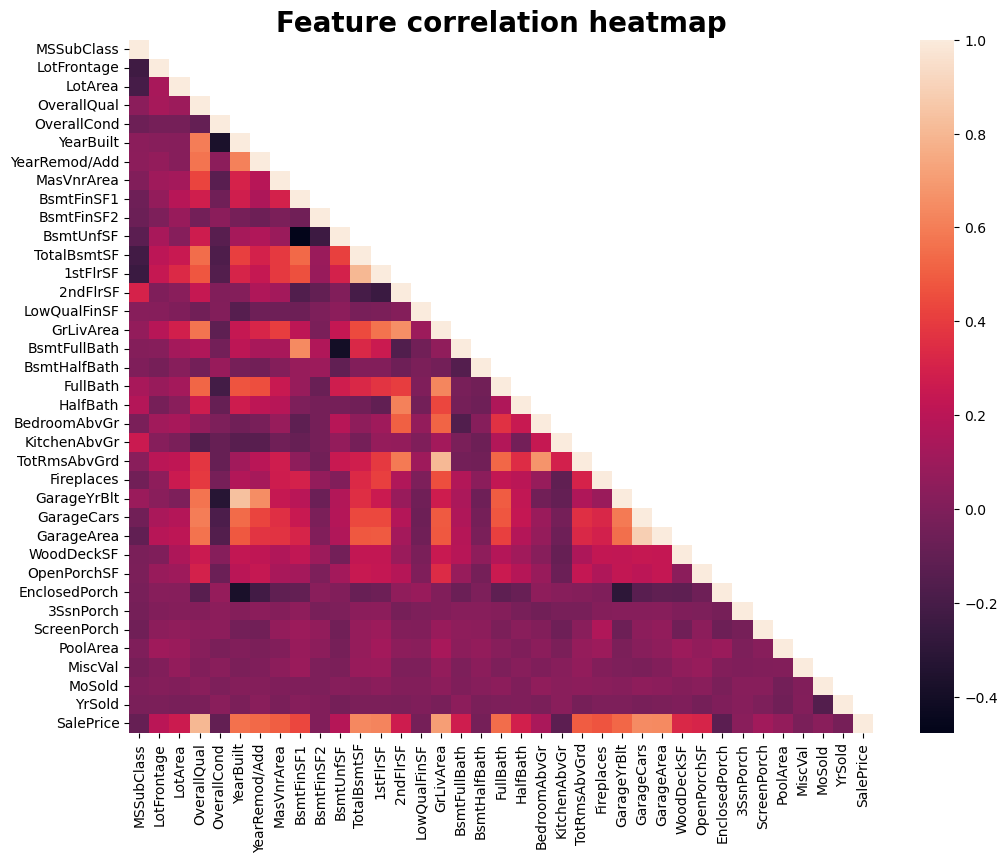

In [86]:
plt.figure(figsize=(12,9))

corr = df_clean.drop(['Order', 'PID'], axis=1).corr(numeric_only=True)
mask = np.triu(corr, k=1)

plt.title('Feature correlation heatmap', fontsize=20, fontweight='bold')
sns.heatmap(corr, annot=False, cbar=True, mask=mask)
plt.show()

At first sight, we can see that the `Overall Qual` column is highly correlated with our target - `SalePrice`, as well as some of the columns realted with areas of certain facilities in the house such as: `GrLivArea`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`. Also it is positively corelated with `YearBuilt`, `YearRemod/Add`, `TotRmsAbvGrd`, `FullBath`, `Fireplaces` and `GarageCars`.

This heatmap also reveals multicollinearity berwqeen features in the dataset - we can notice that `TotRmsAbvGrd` and `GrLivArea` are highly correlated which is reasonable - the larger the living area, the more rooms you can fit in the house. The same goes with `GarageArea` and `GarageCars`.

### Let's visualize the target against the most correlated feature

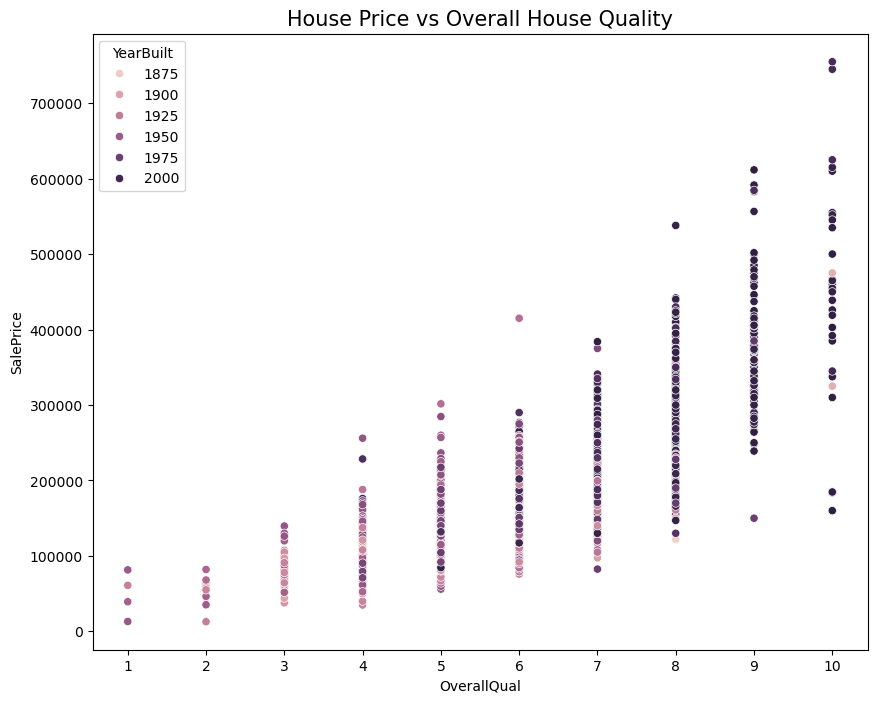

In [87]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='OverallQual',y='SalePrice', data=df_clean, hue='YearBuilt')

plt.xticks(range(1,11))
plt.title('House Price vs Overall House Quality', fontsize=15)

plt.show()

We can see that increase in overall house quality leads to its increased sale price. Also, the year in which the house was built affect its overall quality - older houses tend to be in a worse condition than the newer ones.

Simple regression plot to observe the relation between House Quality and House Price 

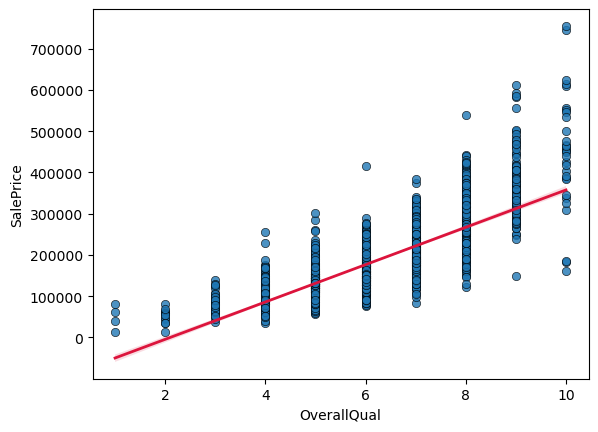

In [88]:
sns.regplot(x='OverallQual', y='SalePrice', data=df_clean, line_kws={'color': 'crimson', 'linewidth': 2}, scatter_kws={'edgecolor':'black', 'linewidths':0.5})
plt.show()

## 2.2) Relationships between the target and other features

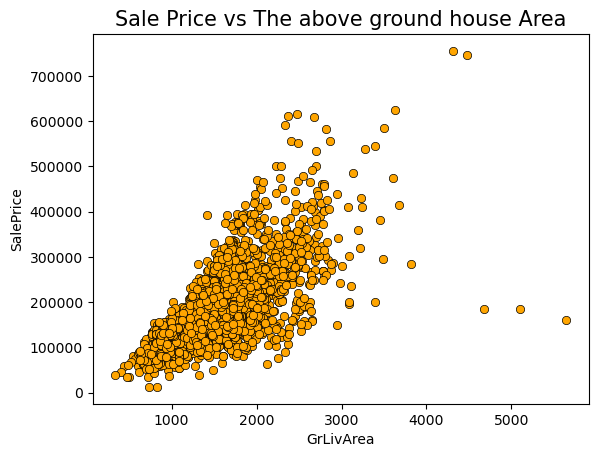

In [91]:
sns.scatterplot(data=df_clean, x='GrLivArea', y='SalePrice', color ='orange', linewidths=0.5, edgecolors='black')
plt.title('Sale Price vs The above ground house Area', fontsize=15)
plt.show()

From this scatter plot we can observe, that there are 5 significant outliers in the dataset, whose house area exceeds 4000 SF. In this case, they will be dropped to avoid model overfitting.

In [92]:
df_clean = df_clean[df_clean['GrLivArea'] < 4000]
df_clean.reset_index(drop=True, inplace=True)

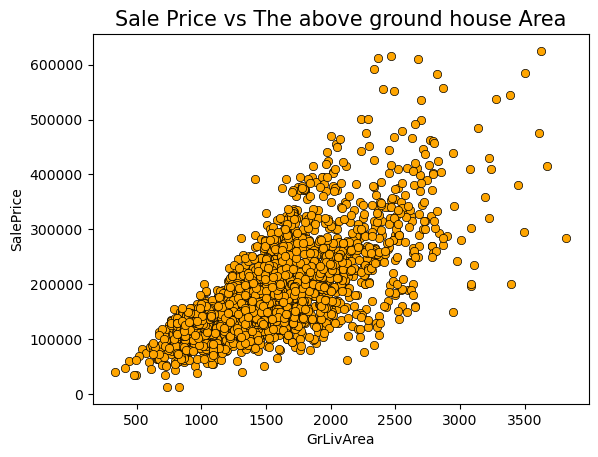

In [96]:
sns.scatterplot(data=df_clean, x='GrLivArea', y='SalePrice', color ='orange', linewidths=0.5, edgecolors='black')
plt.title('Sale Price vs The above ground house Area', fontsize=15)
plt.show()

There is a strong positive correlation between `GrLivArea` and `SalePrice`, making it potentially one of the most important features in modelling alongside with `OverallQual`.

Let's plot the relationships between the rest of moderately correlated features with our target. 

In [135]:
def plot_relations(col_names, nrows=1, ncols=4):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(19,5), sharey=True)

    for i, col in enumerate(col_names):
        ax[i].scatter(data=df_clean, x=col, y='SalePrice', color='orange', edgecolors='black', linewidths=0.5)
        ax[i].set_xlabel(col, fontsize=12, fontweight='bold')
    ax[0].set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

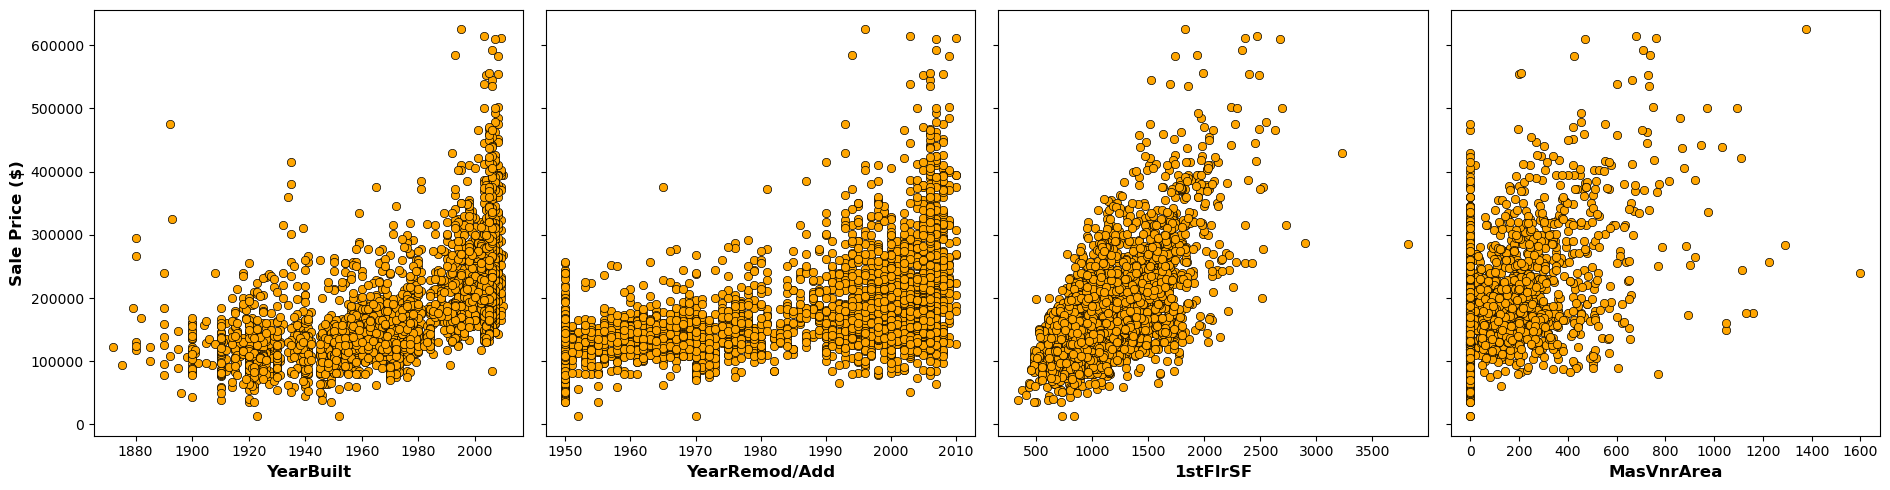

In [98]:
plot_relations(['YearBuilt','YearRemod/Add', '1stFlrSF', 'MasVnrArea'])

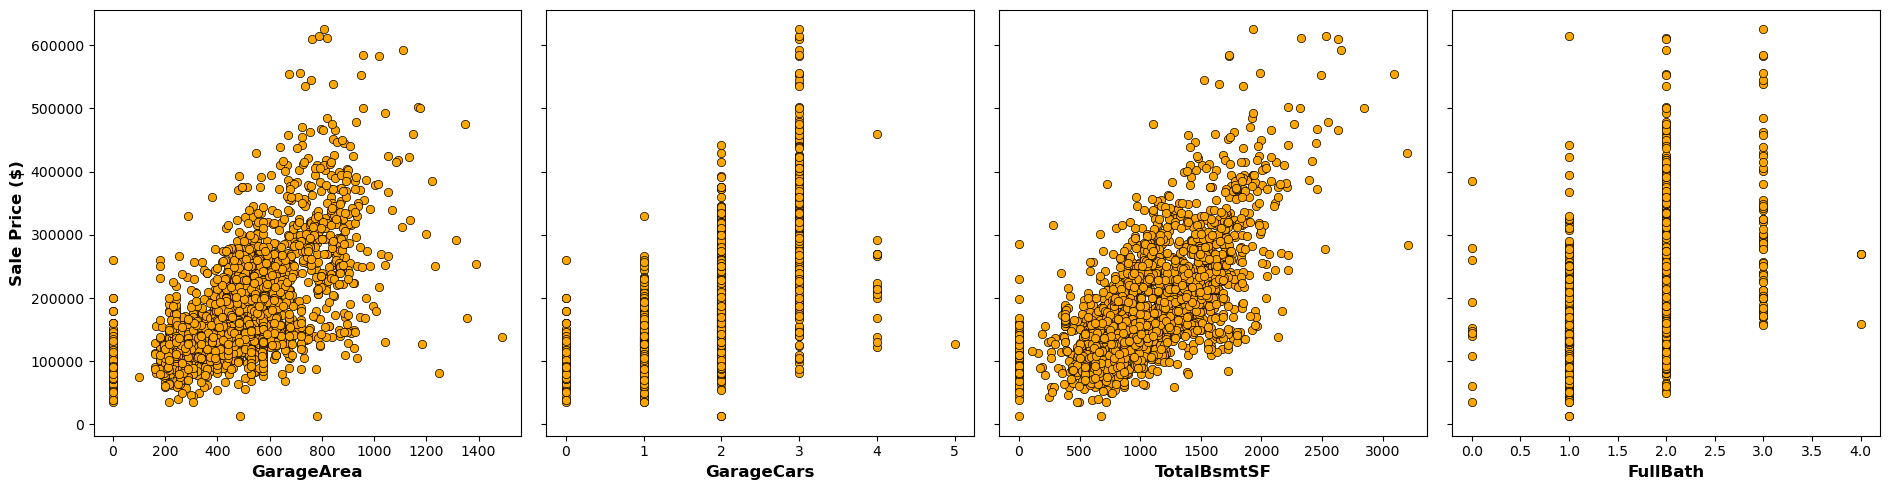

In [99]:
plot_relations(['GarageArea','GarageCars', 'TotalBsmtSF', 'FullBath'])

We can see that these relationships are somewhat strong (such as `TotalBsmtSF` or `GarageArea`), yet not that significant as with `OverallQual` or `GrLivArea`. 

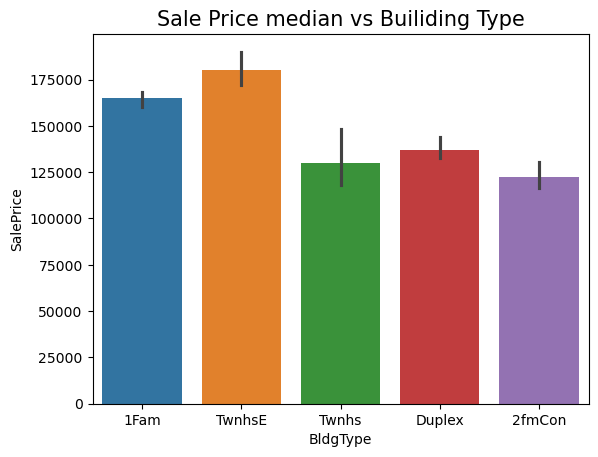

In [ ]:
sns.barplot(data=df_clean, x='BldgType', y='SalePrice',  hue='BldgType', estimator='median')
plt.title('Sale Price median vs Builiding Type', fontsize=15)
plt.show()

From this barplot we can observe that `TwnhsE` - **Townhouse End Unit**s have the highest Sale Price median of around $175K, whereas `2fmCon` - **Two-family Conversion** units have the lowest one of only about $125K.

## 2.3) Target distribution

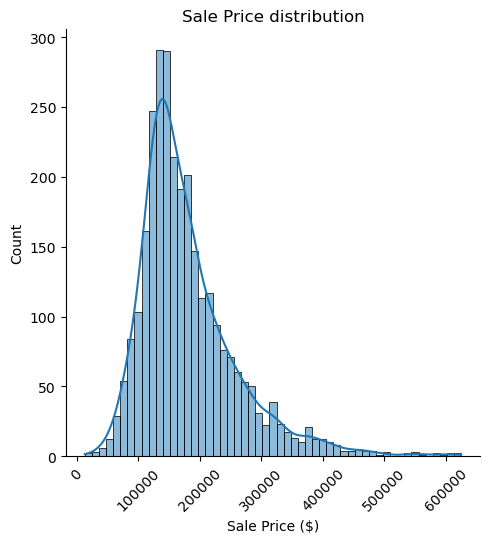

In [107]:
sns.displot(data=df_clean, x='SalePrice', kde=True)
plt.title('Sale Price distribution')
plt.xlabel('Sale Price ($)')
plt.xticks(rotation=45)
plt.show()

We can see that the SalePrice distribution is highly right-skewed, with majority of the houses priced between $100K and $200K and a long rightward tail of expensive houses.

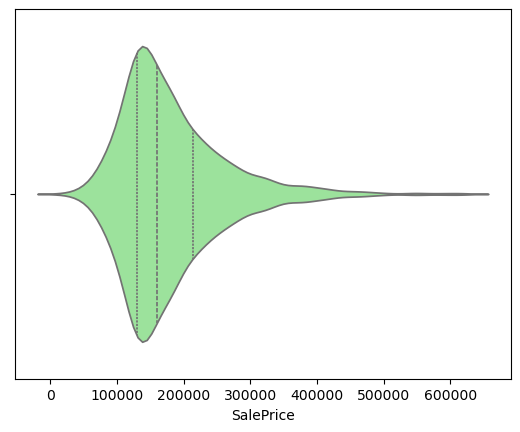

In [ ]:
sns.violinplot(data=df_clean, x='SalePrice', inner='quartile', color='lightgreen')
plt.show()

Statistical measures such as skewness and kurtosis confirm these observations, making `SalePrice` column a good candidate for **log transformation**.

In [113]:
print(f'Sale Price skewness: {df_clean['SalePrice'].skew():.2f}')
print(f'Sale Price kurtosis: {df_clean['SalePrice'].kurt():.2f}')


Sale Price skewness: 1.59
Sale Price kurtosis: 3.84
